# 03 — Patient-Level Analysis

## Objective

This notebook transitions from encounter-level longitudinal analysis to patient-level analysis.

The previous notebook identified substantial clustering of 30-day ED revisits among a small number of high-utilization patients. Therefore, repeated encounters should not be treated as independent patient observations when evaluating patient characteristics associated with ED utilization.

This notebook will:

1. Construct one analytical record per unique patient.
2. Summarize longitudinal ED utilization at the patient level.
3. Characterize demographic and clinical burden.
4. Identify patients with recurrent ED utilization.
5. Compare characteristics across utilization groups.
6. Develop patient-level features for subsequent analytical and visualization work.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Data paths
DATA_PATH = Path("../data/raw")

# Load core tables
patients = pd.read_csv(DATA_PATH / "patients.csv")
encounters = pd.read_csv(DATA_PATH / "encounters.csv")
conditions = pd.read_csv(DATA_PATH / "conditions.csv")

print("Tables loaded:")
print(f"Patients:   {patients.shape}")
print(f"Encounters: {encounters.shape}")
print(f"Conditions: {conditions.shape}")

Tables loaded:
Patients:   (108, 28)
Encounters: (5571, 15)
Conditions: (3517, 7)


In [3]:
# Prepare datetime fields

patients["BIRTHDATE"] = pd.to_datetime(
    patients["BIRTHDATE"],
    errors="coerce",
    utc=True
)

encounters["START"] = pd.to_datetime(
    encounters["START"],
    errors="coerce",
    utc=True
)

encounters["STOP"] = pd.to_datetime(
    encounters["STOP"],
    errors="coerce",
    utc=True
)

conditions["START"] = pd.to_datetime(
    conditions["START"],
    errors="coerce",
    utc=True
)

print("Datetime fields prepared successfully.")

Datetime fields prepared successfully.


In [4]:
# Inspect encounter classes before defining ED encounters

print("ENCOUNTER CLASSES")
print("-" * 50)

print(encounters["ENCOUNTERCLASS"].value_counts(dropna=False))

ENCOUNTER CLASSES
--------------------------------------------------
ENCOUNTERCLASS
ambulatory    2939
wellness      1262
outpatient     759
emergency      270
urgentcare     195
home            63
inpatient       58
snf              9
hospice          8
virtual          8
Name: count, dtype: int64


In [5]:
# Create ED encounter table

ed_encounters = (
    encounters.loc[
        encounters["ENCOUNTERCLASS"].eq("emergency")
    ]
    .copy()
    .sort_values(["PATIENT", "START"])
    .reset_index(drop=True)
)

print("ED ENCOUNTERS")
print("-" * 50)
print(f"ED encounters: {len(ed_encounters):,}")
print(f"Unique ED patients: {ed_encounters['PATIENT'].nunique():,}")
print()

ed_encounters[
    ["Id", "PATIENT", "START", "STOP", "DESCRIPTION"]
].head(10)

ED ENCOUNTERS
--------------------------------------------------
ED encounters: 270
Unique ED patients: 83



,Id,PATIENT,START,STOP,DESCRIPTION
0,00bcbfc6-c7b9-bd0e-eb8c-5a5fd719de83,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2018-01-30 01:16:49+00:00,2018-01-30 02:16:49+00:00,Obstetric emergency hospital admission (proced...
1,029c95e2-d252-d8d3-22a0-9ffcfaa62a10,029c95e2-d252-d8d3-3626-7f347182d6d7,2024-06-17 16:49:02+00:00,2024-06-17 17:49:02+00:00,Emergency room admission (procedure)
2,029c95e2-d252-d8d3-a200-5c4a0ef8b2df,029c95e2-d252-d8d3-3626-7f347182d6d7,2025-10-05 16:49:02+00:00,2025-10-05 17:49:02+00:00,Emergency room admission (procedure)
3,031ce8e2-1443-01b4-f85f-43869f746de5,031ce8e2-1443-01b4-de6b-61a4084a7166,1995-04-12 15:44:09+00:00,1995-04-12 16:44:09+00:00,Emergency room admission (procedure)
4,031ce8e2-1443-01b4-779d-a2b10a00b838,031ce8e2-1443-01b4-de6b-61a4084a7166,1995-06-25 15:44:09+00:00,1995-06-25 16:44:09+00:00,Emergency room admission (procedure)
5,031ce8e2-1443-01b4-078b-8014a8ee8471,031ce8e2-1443-01b4-de6b-61a4084a7166,2000-10-16 00:58:03+00:00,2000-10-16 11:58:03+00:00,Emergency room admission (procedure)
6,031ce8e2-1443-01b4-1069-fa62b19913c4,031ce8e2-1443-01b4-de6b-61a4084a7166,2009-08-25 23:12:41+00:00,2009-08-26 12:12:41+00:00,Emergency room admission (procedure)
7,031ce8e2-1443-01b4-397a-909e34d396da,031ce8e2-1443-01b4-de6b-61a4084a7166,2013-07-07 09:55:05+00:00,2013-07-07 16:55:05+00:00,Emergency room admission (procedure)
8,031ce8e2-1443-01b4-3781-2dfe0466e1b7,031ce8e2-1443-01b4-de6b-61a4084a7166,2013-07-28 16:55:05+00:00,2013-07-29 00:55:05+00:00,Emergency room admission (procedure)
9,031ce8e2-1443-01b4-40d5-34fd89da922b,031ce8e2-1443-01b4-de6b-61a4084a7166,2018-09-23 21:47:05+00:00,2018-09-23 22:47:05+00:00,Emergency room admission (procedure)


In [6]:
# Build patient-level ED utilization table

patient_ed = (
    ed_encounters
    .groupby("PATIENT")
    .agg(
        total_ed_encounters=("Id", "count"),
        first_ed_date=("START", "min"),
        last_ed_date=("START", "max")
    )
    .reset_index()
)

print("PATIENT-LEVEL ED UTILIZATION")
print("-" * 50)

print(f"Rows: {len(patient_ed):,}")
print(f"Unique patients: {patient_ed['PATIENT'].nunique():,}")
print()

print(patient_ed["total_ed_encounters"].describe().round(1))
print()

patient_ed.sort_values(
    "total_ed_encounters",
    ascending=False
).head(15)

PATIENT-LEVEL ED UTILIZATION
--------------------------------------------------
Rows: 83
Unique patients: 83

count    83.0
mean      3.3
std       7.2
min       1.0
25%       1.0
50%       2.0
75%       3.0
max      65.0
Name: total_ed_encounters, dtype: float64



,PATIENT,total_ed_encounters,first_ed_date,last_ed_date
35,5693c080-f485-91e7-54b9-ad9a8c12af62,65,2003-12-25 23:50:14+00:00,2026-08-16 23:50:14+00:00
63,bca1691f-8839-1d66-ed01-471134d55738,13,2014-09-04 11:39:55+00:00,2026-08-12 11:39:55+00:00
22,355a4d50-2628-aa65-c336-deacf4d606fb,10,2004-12-05 20:04:51+00:00,2026-05-07 20:04:51+00:00
12,2211f478-b7b4-7711-16cf-84ffb52b9d2b,9,1986-04-19 15:13:14+00:00,2016-06-03 15:32:10+00:00
20,31f368d9-3fdc-a15f-ccdc-fafa74a860e9,8,1995-02-11 15:44:09+00:00,2024-12-24 13:25:03+00:00
2,031ce8e2-1443-01b4-de6b-61a4084a7166,7,1995-04-12 15:44:09+00:00,2018-09-23 21:47:05+00:00
54,96de62ae-1b00-58d8-77f9-cd25414e16be,6,2017-07-07 12:39:26+00:00,2024-07-16 13:07:04+00:00
56,9c5b16dc-8a47-896c-4d74-f96f8c98891b,5,2019-11-22 02:32:19+00:00,2024-06-13 03:48:47+00:00
21,3314e296-2326-2826-271d-a7be5b896db9,5,2016-10-02 02:18:12+00:00,2025-02-18 03:33:50+00:00
15,2e9a9dab-f5b6-8960-d3ce-7834bb5e7344,4,2017-02-26 18:07:17+00:00,2024-01-07 18:07:17+00:00


In [7]:
# Distribution of ED encounters per patient

ed_frequency = (
    patient_ed["total_ed_encounters"]
    .value_counts()
    .sort_index()
    .rename_axis("total_ed_encounters")
    .reset_index(name="patients")
)

ed_frequency["patient_pct"] = (
    ed_frequency["patients"] / len(patient_ed) * 100
).round(1)

print("ED ENCOUNTER FREQUENCY AT PATIENT LEVEL")
print("-" * 50)
print(ed_frequency.to_string(index=False))

ED ENCOUNTER FREQUENCY AT PATIENT LEVEL
--------------------------------------------------
 total_ed_encounters  patients  patient_pct
                   1        31         37.3
                   2        26         31.3
                   3         9         10.8
                   4         8          9.6
                   5         2          2.4
                   6         1          1.2
                   7         1          1.2
                   8         1          1.2
                   9         1          1.2
                  10         1          1.2
                  13         1          1.2
                  65         1          1.2


In [8]:
# Calculate prior ED encounters within 365 days for each encounter

ed_timeline = (
    ed_encounters[["PATIENT", "START"]]
    .sort_values(["PATIENT", "START"])
    .reset_index(drop=True)
)

def count_prior_ed_365(group):
    dates = group["START"].tolist()
    counts = []

    for i, current_date in enumerate(dates):
        window_start = current_date - pd.Timedelta(days=365)

        prior_count = sum(
            (d < current_date) and (d >= window_start)
            for d in dates[:i]
        )

        counts.append(prior_count)

    group = group.copy()
    group["prior_ed_365d"] = counts
    return group

ed_timeline = (
    ed_timeline
    .groupby("PATIENT", group_keys=False)
    .apply(count_prior_ed_365)
    .reset_index(drop=True)
)

patient_annual_ed = (
    ed_timeline
    .groupby("PATIENT")
    .agg(
        total_ed_encounters=("START", "size"),
        max_prior_ed_365d=("prior_ed_365d", "max")
    )
    .reset_index()
)

print("MAXIMUM PRIOR ED UTILIZATION WITHIN 365 DAYS")
print("-" * 55)

print(
    patient_annual_ed["max_prior_ed_365d"]
    .value_counts()
    .sort_index()
)

patient_annual_ed.sort_values(
    "max_prior_ed_365d",
    ascending=False
).head(15)

MAXIMUM PRIOR ED UTILIZATION WITHIN 365 DAYS
-------------------------------------------------------
max_prior_ed_365d
0     59
1     18
2      3
5      1
9      1
48     1
Name: count, dtype: int64


C:\Users\Denisse Pareja\AppData\Local\Temp\ipykernel_21144\2914943838.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_prior_ed_365)


,PATIENT,total_ed_encounters,max_prior_ed_365d
35,5693c080-f485-91e7-54b9-ad9a8c12af62,65,48
63,bca1691f-8839-1d66-ed01-471134d55738,13,9
22,355a4d50-2628-aa65-c336-deacf4d606fb,10,5
36,57efda89-b582-bb08-8a2d-e06b2c184bfc,3,2
51,8d91c36a-1f7e-3842-9f14-8d567ed9cdcd,4,2
20,31f368d9-3fdc-a15f-ccdc-fafa74a860e9,8,2
12,2211f478-b7b4-7711-16cf-84ffb52b9d2b,9,1
15,2e9a9dab-f5b6-8960-d3ce-7834bb5e7344,4,1
55,9a3814bb-f5b0-05f3-928e-fe6640d5aa2a,2,1
78,f6359fe4-4340-2820-8b76-593a45f5186c,4,1


In [9]:
# Create peak annual ED utilization and frequent-utilizer flag

patient_annual_ed["peak_ed_365d"] = (
    patient_annual_ed["max_prior_ed_365d"] + 1
)

patient_annual_ed["frequent_ed_utilizer"] = (
    patient_annual_ed["peak_ed_365d"] >= 4
)

print("FREQUENT ED UTILIZATION")
print("-" * 50)

print(
    patient_annual_ed["frequent_ed_utilizer"]
    .value_counts()
)

print()

print(
    patient_annual_ed.groupby("frequent_ed_utilizer")[
        ["total_ed_encounters", "peak_ed_365d"]
    ]
    .agg(["count", "mean", "median", "max"])
    .round(1)
)

print("\nPatients meeting frequent-utilizer definition:")

patient_annual_ed.loc[
    patient_annual_ed["frequent_ed_utilizer"]
].sort_values(
    "peak_ed_365d",
    ascending=False
)

FREQUENT ED UTILIZATION
--------------------------------------------------
frequent_ed_utilizer
False    80
True      3
Name: count, dtype: int64

                     total_ed_encounters                  peak_ed_365d                 
                                   count  mean median max        count  mean median max
frequent_ed_utilizer                                                                   
False                                 80   2.3    2.0   9           80   1.3    1.0   3
True                                   3  29.3   13.0  65            3  21.7   10.0  49

Patients meeting frequent-utilizer definition:


,PATIENT,total_ed_encounters,max_prior_ed_365d,peak_ed_365d,frequent_ed_utilizer
35,5693c080-f485-91e7-54b9-ad9a8c12af62,65,48,49,True
63,bca1691f-8839-1d66-ed01-471134d55738,13,9,10,True
22,355a4d50-2628-aa65-c336-deacf4d606fb,10,5,6,True


In [11]:
# Add patient demographic characteristics

patient_demo = patients[
    ["Id", "BIRTHDATE", "GENDER"]
].copy()

patient_demo = patient_demo.rename(
    columns={
        "Id": "PATIENT",
        "GENDER": "gender"
    }
)

# Merge annual ED utilization with first/last ED dates
patient_demo_ed = patient_annual_ed.merge(
    patient_ed[
        ["PATIENT", "first_ed_date", "last_ed_date"]
    ],
    on="PATIENT",
    how="left"
)

# Merge demographics
patient_demo_ed = patient_demo_ed.merge(
    patient_demo,
    on="PATIENT",
    how="left"
)

# Calculate age at last ED encounter
patient_demo_ed["age_at_last_ed"] = (
    (
        patient_demo_ed["last_ed_date"] -
        patient_demo_ed["BIRTHDATE"]
    ).dt.days / 365.25
).round(1)

print("PATIENT DEMOGRAPHIC PROFILE")
print("-" * 50)

print(f"Rows: {len(patient_demo_ed):,}")
print(f"Missing gender: {patient_demo_ed['gender'].isna().sum():,}")
print(f"Missing age: {patient_demo_ed['age_at_last_ed'].isna().sum():,}")

print("\nAge distribution:")
print(
    patient_demo_ed["age_at_last_ed"]
    .describe()
    .round(1)
)

print("\nGender distribution:")
print(
    patient_demo_ed["gender"]
    .value_counts(dropna=False)
)

patient_demo_ed[
    [
        "PATIENT",
        "total_ed_encounters",
        "peak_ed_365d",
        "frequent_ed_utilizer",
        "age_at_last_ed",
        "gender"
    ]
].sort_values(
    "total_ed_encounters",
    ascending=False
).head(15)

PATIENT DEMOGRAPHIC PROFILE
--------------------------------------------------
Rows: 83
Missing gender: 0
Missing age: 0

Age distribution:
count    83.0
mean     34.4
std      20.4
min       0.0
25%      19.2
50%      32.9
75%      49.2
max      92.6
Name: age_at_last_ed, dtype: float64

Gender distribution:
gender
M    43
F    40
Name: count, dtype: int64


,PATIENT,total_ed_encounters,peak_ed_365d,frequent_ed_utilizer,age_at_last_ed,gender
35,5693c080-f485-91e7-54b9-ad9a8c12af62,65,49,True,53.4,M
63,bca1691f-8839-1d66-ed01-471134d55738,13,10,True,81.8,M
22,355a4d50-2628-aa65-c336-deacf4d606fb,10,6,True,69.5,M
12,2211f478-b7b4-7711-16cf-84ffb52b9d2b,9,2,False,31.7,F
20,31f368d9-3fdc-a15f-ccdc-fafa74a860e9,8,3,False,44.0,M
2,031ce8e2-1443-01b4-de6b-61a4084a7166,7,2,False,37.7,M
54,96de62ae-1b00-58d8-77f9-cd25414e16be,6,2,False,26.0,F
56,9c5b16dc-8a47-896c-4d74-f96f8c98891b,5,2,False,44.4,M
21,3314e296-2326-2826-271d-a7be5b896db9,5,2,False,34.7,F
15,2e9a9dab-f5b6-8960-d3ce-7834bb5e7344,4,2,False,34.0,F


In [12]:
# Build patient-level documented clinical condition burden

condition_patient = (
    conditions[
        ["PATIENT", "CODE", "DESCRIPTION"]
    ]
    .dropna(subset=["PATIENT"])
    .drop_duplicates(
        subset=["PATIENT", "CODE"]
    )
)

patient_conditions = (
    condition_patient
    .groupby("PATIENT")
    .agg(
        unique_condition_count=("CODE", "nunique")
    )
    .reset_index()
)

# Merge clinical burden with patient-level ED profile
patient_profile = patient_demo_ed.merge(
    patient_conditions,
    on="PATIENT",
    how="left"
)

patient_profile["unique_condition_count"] = (
    patient_profile["unique_condition_count"]
    .fillna(0)
    .astype(int)
)

print("PATIENT-LEVEL CLINICAL BURDEN")
print("-" * 50)

print(
    patient_profile["unique_condition_count"]
    .describe()
    .round(1)
)

print("\nClinical burden by frequent ED utilization:")

print(
    patient_profile
    .groupby("frequent_ed_utilizer")[
        "unique_condition_count"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

print("\nHighest ED-utilization patients:")

patient_profile[
    [
        "PATIENT",
        "total_ed_encounters",
        "peak_ed_365d",
        "frequent_ed_utilizer",
        "age_at_last_ed",
        "gender",
        "unique_condition_count"
    ]
].sort_values(
    "total_ed_encounters",
    ascending=False
).head(15)

PATIENT-LEVEL CLINICAL BURDEN
--------------------------------------------------
count    83.0
mean     20.0
std       9.0
min       3.0
25%      13.5
50%      20.0
75%      25.0
max      53.0
Name: unique_condition_count, dtype: float64

Clinical burden by frequent ED utilization:
                      count  mean  median  min  max
frequent_ed_utilizer                               
False                    80  19.0    20.0    3   40
True                      3  44.0    42.0   37   53

Highest ED-utilization patients:


,PATIENT,total_ed_encounters,peak_ed_365d,frequent_ed_utilizer,age_at_last_ed,gender,unique_condition_count
35,5693c080-f485-91e7-54b9-ad9a8c12af62,65,49,True,53.4,M,37
63,bca1691f-8839-1d66-ed01-471134d55738,13,10,True,81.8,M,53
22,355a4d50-2628-aa65-c336-deacf4d606fb,10,6,True,69.5,M,42
12,2211f478-b7b4-7711-16cf-84ffb52b9d2b,9,2,False,31.7,F,40
20,31f368d9-3fdc-a15f-ccdc-fafa74a860e9,8,3,False,44.0,M,28
2,031ce8e2-1443-01b4-de6b-61a4084a7166,7,2,False,37.7,M,18
54,96de62ae-1b00-58d8-77f9-cd25414e16be,6,2,False,26.0,F,26
56,9c5b16dc-8a47-896c-4d74-f96f8c98891b,5,2,False,44.4,M,21
21,3314e296-2326-2826-271d-a7be5b896db9,5,2,False,34.7,F,18
15,2e9a9dab-f5b6-8960-d3ce-7834bb5e7344,4,2,False,34.0,F,21


In [13]:
# Examine documented conditions among frequent ED utilizers

frequent_patient_ids = patient_profile.loc[
    patient_profile["frequent_ed_utilizer"],
    "PATIENT"
]

frequent_conditions = (
    condition_patient[
        condition_patient["PATIENT"].isin(frequent_patient_ids)
    ]
    .merge(
        patient_profile[
            [
                "PATIENT",
                "total_ed_encounters",
                "peak_ed_365d",
                "age_at_last_ed",
                "gender"
            ]
        ],
        on="PATIENT",
        how="left"
    )
)

# Conditions shared across frequent utilizers
condition_summary = (
    frequent_conditions
    .groupby(["CODE", "DESCRIPTION"])
    .agg(
        patients=("PATIENT", "nunique")
    )
    .reset_index()
    .sort_values(
        ["patients", "DESCRIPTION"],
        ascending=[False, True]
    )
)

print("CONDITIONS AMONG FREQUENT ED UTILIZERS")
print("-" * 55)

print(f"Frequent ED utilizers: {len(frequent_patient_ids)}")
print(
    f"Unique documented conditions: "
    f"{frequent_conditions['CODE'].nunique()}"
)

print("\nConditions documented in multiple frequent utilizers:")

shared_conditions = condition_summary[
    condition_summary["patients"] >= 2
]

print(
    shared_conditions[
        ["DESCRIPTION", "patients"]
    ].to_string(index=False)
)

print("\nCondition count for each frequent utilizer:")

print(
    frequent_conditions
    .groupby(
        [
            "PATIENT",
            "age_at_last_ed",
            "gender",
            "total_ed_encounters",
            "peak_ed_365d"
        ]
    )
    .agg(
        unique_conditions=("CODE", "nunique")
    )
    .reset_index()
    .sort_values(
        "total_ed_encounters",
        ascending=False
    )
    .to_string(index=False)
)

CONDITIONS AMONG FREQUENT ED UTILIZERS
-------------------------------------------------------
Frequent ED utilizers: 3
Unique documented conditions: 74

Conditions documented in multiple frequent utilizers:
                                                           DESCRIPTION  patients
Abnormal findings diagnostic imaging heart+coronary circulat (finding)         3
                                                     Anemia (disorder)         3
                             Chronic kidney disease stage 1 (disorder)         3
                Disorder of kidney due to diabetes mellitus (disorder)         3
                                        Full-time employment (finding)         3
                                                 Gingivitis (disorder)         3
                History of coronary artery bypass grafting (situation)         3
                                         Infection of tooth (disorder)         3
                                     Ischemic heart disease (di

In [14]:
# Examine longitudinal observation time by patient

patient_history = (
    encounters
    .groupby("PATIENT")
    .agg(
        first_record_date=("START", "min"),
        last_record_date=("START", "max"),
        total_all_encounters=("Id", "count")
    )
    .reset_index()
)

patient_history["observation_years"] = (
    (
        patient_history["last_record_date"] -
        patient_history["first_record_date"]
    ).dt.days / 365.25
).round(1)

patient_profile = patient_profile.merge(
    patient_history,
    on="PATIENT",
    how="left"
)

print("LONGITUDINAL OBSERVATION TIME")
print("-" * 55)

print("\nOverall:")
print(
    patient_profile["observation_years"]
    .describe()
    .round(1)
)

print("\nBy frequent ED utilization:")
print(
    patient_profile
    .groupby("frequent_ed_utilizer")
    ["observation_years"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

print("\nFrequent ED utilizers:")
print(
    patient_profile.loc[
        patient_profile["frequent_ed_utilizer"],
        [
            "PATIENT",
            "age_at_last_ed",
            "total_ed_encounters",
            "peak_ed_365d",
            "unique_condition_count",
            "observation_years",
            "total_all_encounters"
        ]
    ]
    .sort_values(
        "total_ed_encounters",
        ascending=False
    )
    .to_string(index=False)
)

LONGITUDINAL OBSERVATION TIME
-------------------------------------------------------

Overall:
count    83.0
mean     28.3
std      18.9
min       1.4
25%      12.0
50%      23.5
75%      40.0
max      83.7
Name: observation_years, dtype: float64

By frequent ED utilization:
                      count  mean  median   min   max
frequent_ed_utilizer                                 
False                    80  27.0    22.2   1.4  83.7
True                      3  61.5    69.7  35.2  79.5

Frequent ED utilizers:
                             PATIENT  age_at_last_ed  total_ed_encounters  peak_ed_365d  unique_condition_count  observation_years  total_all_encounters
5693c080-f485-91e7-54b9-ad9a8c12af62            53.4                   65            49                      37               35.2                   129
bca1691f-8839-1d66-ed01-471134d55738            81.8                   13            10                      53               79.5                   453
355a4d50-2628-aa65-c336-

In [15]:
# Normalize documented condition burden by observation time

patient_profile["conditions_per_observation_year"] = (
    patient_profile["unique_condition_count"] /
    patient_profile["observation_years"]
)

print("NORMALIZED CLINICAL BURDEN")
print("-" * 55)

print("\nConditions per observation year:")
print(
    patient_profile
    .groupby("frequent_ed_utilizer")
    ["conditions_per_observation_year"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nFrequent ED utilizers:")
print(
    patient_profile.loc[
        patient_profile["frequent_ed_utilizer"],
        [
            "PATIENT",
            "age_at_last_ed",
            "unique_condition_count",
            "observation_years",
            "conditions_per_observation_year",
            "total_ed_encounters",
            "peak_ed_365d"
        ]
    ]
    .sort_values(
        "total_ed_encounters",
        ascending=False
    )
    .round(2)
    .to_string(index=False)
)

NORMALIZED CLINICAL BURDEN
-------------------------------------------------------

Conditions per observation year:
                      count  mean  median   min   max
frequent_ed_utilizer                                 
False                    80  0.91    0.76  0.36  2.43
True                      3  0.77    0.67  0.60  1.05

Frequent ED utilizers:
                             PATIENT  age_at_last_ed  unique_condition_count  observation_years  conditions_per_observation_year  total_ed_encounters  peak_ed_365d
5693c080-f485-91e7-54b9-ad9a8c12af62            53.4                      37               35.2                             1.05                   65            49
bca1691f-8839-1d66-ed01-471134d55738            81.8                      53               79.5                             0.67                   13            10
355a4d50-2628-aa65-c336-deacf4d606fb            69.5                      42               69.7                             0.60                   10  

In [16]:
# Quantify concentration of ED utilization among frequent utilizers

total_ed = patient_profile["total_ed_encounters"].sum()

frequent_ed = patient_profile.loc[
    patient_profile["frequent_ed_utilizer"],
    "total_ed_encounters"
].sum()

frequent_patients = patient_profile["frequent_ed_utilizer"].sum()
total_patients = len(patient_profile)

patient_share = frequent_patients / total_patients * 100
encounter_share = frequent_ed / total_ed * 100

print("ED UTILIZATION CONCENTRATION")
print("-" * 55)

print(f"ED patients: {total_patients}")
print(f"Total ED encounters: {total_ed}")

print(
    f"\nFrequent utilizers: "
    f"{frequent_patients} "
    f"({patient_share:.1f}% of ED patients)"
)

print(
    f"ED encounters generated by frequent utilizers: "
    f"{frequent_ed} "
    f"({encounter_share:.1f}% of all ED encounters)"
)

print("\nIndividual frequent-utilizer contribution:")

frequent_contribution = (
    patient_profile.loc[
        patient_profile["frequent_ed_utilizer"],
        [
            "PATIENT",
            "total_ed_encounters",
            "peak_ed_365d",
            "age_at_last_ed",
            "gender"
        ]
    ]
    .copy()
)

frequent_contribution["share_all_ed_pct"] = (
    frequent_contribution["total_ed_encounters"]
    / total_ed * 100
).round(1)

print(
    frequent_contribution
    .sort_values("total_ed_encounters", ascending=False)
    .to_string(index=False)
)

ED UTILIZATION CONCENTRATION
-------------------------------------------------------
ED patients: 83
Total ED encounters: 270

Frequent utilizers: 3 (3.6% of ED patients)
ED encounters generated by frequent utilizers: 88 (32.6% of all ED encounters)

Individual frequent-utilizer contribution:
                             PATIENT  total_ed_encounters  peak_ed_365d  age_at_last_ed gender  share_all_ed_pct
5693c080-f485-91e7-54b9-ad9a8c12af62                   65            49            53.4      M              24.1
bca1691f-8839-1d66-ed01-471134d55738                   13            10            81.8      M               4.8
355a4d50-2628-aa65-c336-deacf4d606fb                   10             6            69.5      M               3.7


In [17]:
# Sensitivity analysis: exclude the highest-utilization patient

top_patient_id = (
    patient_profile
    .sort_values("total_ed_encounters", ascending=False)
    .iloc[0]["PATIENT"]
)

sensitivity = patient_profile[
    patient_profile["PATIENT"] != top_patient_id
].copy()

total_ed_without_top = sensitivity["total_ed_encounters"].sum()

frequent_without_top = sensitivity[
    sensitivity["frequent_ed_utilizer"]
]

frequent_ed_without_top = (
    frequent_without_top["total_ed_encounters"].sum()
)

patient_share_without_top = (
    len(frequent_without_top) /
    len(sensitivity) * 100
)

encounter_share_without_top = (
    frequent_ed_without_top /
    total_ed_without_top * 100
)

print("SENSITIVITY ANALYSIS — EXCLUDING TOP ED UTILIZER")
print("-" * 60)

print(f"Patients remaining: {len(sensitivity)}")
print(f"ED encounters remaining: {total_ed_without_top}")

print(
    f"\nRemaining frequent utilizers: "
    f"{len(frequent_without_top)} "
    f"({patient_share_without_top:.1f}% of patients)"
)

print(
    f"ED encounters generated by remaining frequent utilizers: "
    f"{frequent_ed_without_top} "
    f"({encounter_share_without_top:.1f}% of ED encounters)"
)

print("\nHighest utilization after exclusion:")

print(
    sensitivity[
        [
            "PATIENT",
            "total_ed_encounters",
            "peak_ed_365d",
            "frequent_ed_utilizer"
        ]
    ]
    .sort_values(
        "total_ed_encounters",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

SENSITIVITY ANALYSIS — EXCLUDING TOP ED UTILIZER
------------------------------------------------------------
Patients remaining: 82
ED encounters remaining: 205

Remaining frequent utilizers: 2 (2.4% of patients)
ED encounters generated by remaining frequent utilizers: 23 (11.2% of ED encounters)

Highest utilization after exclusion:
                             PATIENT  total_ed_encounters  peak_ed_365d  frequent_ed_utilizer
bca1691f-8839-1d66-ed01-471134d55738                   13            10                  True
355a4d50-2628-aa65-c336-deacf4d606fb                   10             6                  True
2211f478-b7b4-7711-16cf-84ffb52b9d2b                    9             2                 False
31f368d9-3fdc-a15f-ccdc-fafa74a860e9                    8             3                 False
031ce8e2-1443-01b4-de6b-61a4084a7166                    7             2                 False
96de62ae-1b00-58d8-77f9-cd25414e16be                    6             2                 False
9c5b1

In [21]:
# Create clinically interpretable ED utilization segments

def assign_utilization_segment(row):
    if row["frequent_ed_utilizer"]:
        return "Frequent"
    elif row["total_ed_encounters"] >= 4:
        return "Moderate"
    elif row["total_ed_encounters"] >= 2:
        return "Low"
    else:
        return "Single-use"


patient_profile["utilization_segment"] = (
    patient_profile.apply(
        assign_utilization_segment,
        axis=1
    )
)

segment_order = [
    "Single-use",
    "Low",
    "Moderate",
    "Frequent"
]

segment_summary = (
    patient_profile
    .groupby("utilization_segment")
    .agg(
        patients=("PATIENT", "nunique"),
        total_ed_encounters=("total_ed_encounters", "sum"),
        median_ed_encounters=("total_ed_encounters", "median"),
        median_peak_365d=("peak_ed_365d", "median"),
        median_age=("age_at_last_ed", "median")
    )
    .reindex(segment_order)
)

segment_summary["patient_share_pct"] = (
    segment_summary["patients"] /
    segment_summary["patients"].sum() * 100
).round(1)

segment_summary["ed_encounter_share_pct"] = (
    segment_summary["total_ed_encounters"] /
    segment_summary["total_ed_encounters"].sum() * 100
).round(1)

print("ED UTILIZATION SEGMENTS")
print("-" * 60)

print(segment_summary)

ED UTILIZATION SEGMENTS
------------------------------------------------------------
                     patients  total_ed_encounters  median_ed_encounters  median_peak_365d  median_age  patient_share_pct  \
utilization_segment                                                                                                         
Single-use                 31                   31                   1.0               1.0       20.10               37.3   
Low                        35                   79                   2.0               1.0       36.10               42.2   
Moderate                   14                   72                   4.0               2.0       34.05               16.9   
Frequent                    3                   88                  13.0              10.0       69.50                3.6   

                     ed_encounter_share_pct  
utilization_segment                          
Single-use                             11.5  
Low                       

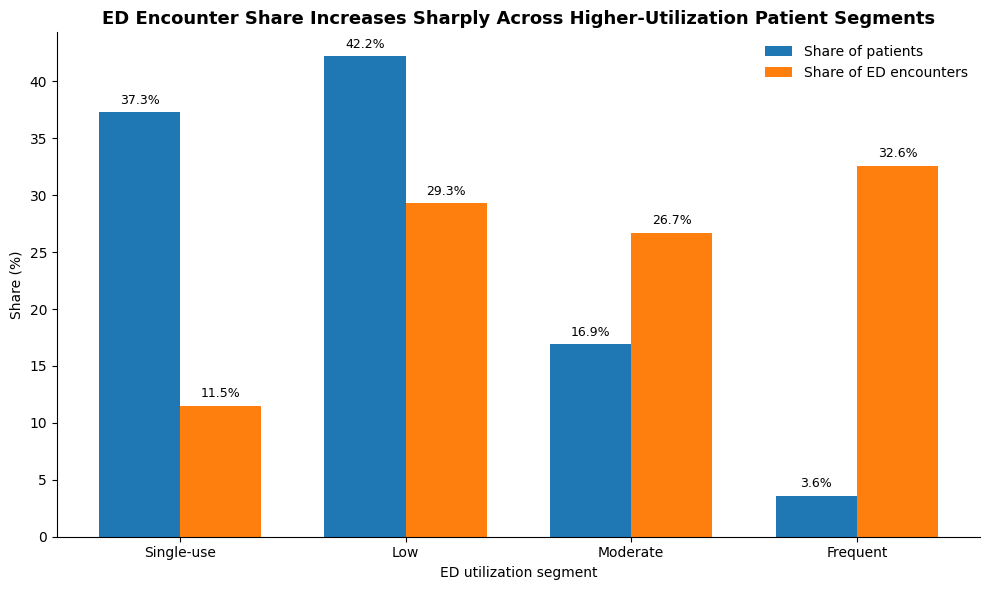

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
plot_df = segment_summary.reset_index()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    plot_df["patient_share_pct"],
    width,
    label="Share of patients"
)

bars2 = ax.bar(
    x + width/2,
    plot_df["ed_encounter_share_pct"],
    width,
    label="Share of ED encounters"
)

ax.set_title(
    "ED Encounter Share Increases Sharply Across Higher-Utilization Patient Segments",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("Share (%)")
ax.set_xlabel("ED utilization segment")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["utilization_segment"])

ax.legend(frameon=False)

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../reports/figures/ed_utilization_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Build summary profile by ED utilization segment

segment_profile = (
    patient_profile
    .groupby("utilization_segment")
    .agg(
        patients=("PATIENT", "nunique"),
        median_age=("age_at_last_ed", "median"),
        median_total_ed=("total_ed_encounters", "median"),
        median_peak_365d=("peak_ed_365d", "median"),
        median_conditions=("unique_condition_count", "median"),
        median_conditions_per_year=("conditions_per_observation_year", "median"),
        median_observation_years=("observation_years", "median")
    )
    .reindex([
        "Single-use",
        "Low",
        "Moderate",
        "Frequent"
    ])
    .round(1)
)

print("PATIENT PROFILE BY ED UTILIZATION SEGMENT")
print("-" * 65)

print(segment_profile)

PATIENT PROFILE BY ED UTILIZATION SEGMENT
-----------------------------------------------------------------
                     patients  median_age  median_total_ed  median_peak_365d  median_conditions  median_conditions_per_year  \
utilization_segment                                                                                                           
Single-use                 31        20.1              1.0               1.0               14.0                         0.7   
Low                        35        36.1              2.0               1.0               22.0                         0.7   
Moderate                   14        34.0              4.0               2.0               21.0                         0.8   
Frequent                    3        69.5             13.0              10.0               42.0                         0.7   

                     median_observation_years  
utilization_segment                            
Single-use                       

## Key Findings

- ED utilization was highly heterogeneous across the 83 patients with documented emergency encounters.
- Three patients (3.6% of ED patients) met the frequent-utilizer definition of ≥4 ED encounters within a rolling 365-day period.
- These three patients accounted for 88 of 270 ED encounters (32.6%), although utilization was strongly influenced by one patient with 65 encounters.
- Sensitivity analysis excluding the highest-utilization patient reduced the frequent-utilizer contribution to 11.2% of remaining ED encounters, demonstrating the importance of evaluating patient-level outliers.
- Higher-utilization segments showed progressively greater encounter intensity: median lifetime ED encounters increased from 1 among single-use patients to 13 among frequent utilizers, while median peak annual utilization increased from 1 to 10 encounters.
- Frequent utilizers had a higher documented condition count (median 42), but also substantially longer longitudinal observation (median 69.7 years). After normalization, documented conditions per observation year were similar across utilization segments (approximately 0.7–0.8).
- These findings are descriptive and should not be interpreted as population-level associations because of the small cohort and the very small number of frequent ED utilizers.